# NYC Bike Data: Dataset Description & Exploratory Analysis

This notebook documents and explores every dataset used in the project and underpins the
**technical report** in `docs/technical-report/`. It covers, in order of importance:

1. **Citi Bike dataset**: the project's main data source with bike trip records (one monthly file, downloaded manually).
2. **Station metadata**: current Citi Bike stations from the Lyft GBFS feed (fetched live).
3. **Weather**: hourly NYC observations from the Open-Meteo archive (fetched live).
4. **Bike lanes**: NYC bike-route network from NYC OpenData (fetched live).

For each dataset we describe its **structure**, run **exploratory data analysis (EDA)**, and
assess **data quality**. See `src/notebooks/README.md` for how to obtain the ride data and run
this notebook.

## 0. Setup

In [88]:
import json
import re
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Where to find the manually-downloaded Citi Bike monthly CSV(s) (relative to this notebook).
DATA_DIR = Path("data")

# Data sources (mirrors src/ingestion/config.yaml and src/backend/config.yaml).
WEATHER_API_URL = "https://archive-api.open-meteo.com/v1/archive"
BIKE_ROUTES_URL = "https://data.cityofnewyork.us/api/views/mzxg-pwib/rows.csv?accessType=DOWNLOAD"
GBFS_INFO_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"
GBFS_STATUS_URL = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_status.json"
NYC_LAT, NYC_LON = 40.7823234, -73.9654161

# Distance-feature constants (see src/ingestion/sources/distances.py).
EARTH_RADIUS_KM = 6371
STREET_CIRCUITY_FACTOR = 1.3

Here we define an utility function for computing the Haversine distance calculated as:

$$d = 2 r \arcsin \sqrt{\sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1) \cos(\phi_2) \sin^2\left(\frac{\Delta \lambda}{2}\right)}$$

where $\phi$ is latitude, $\lambda$ is longitude, and $r$ is the Earth's radius (6371 km).

In [89]:
# Vectorised great-circle distance (km) scaled by the street-circuity factor,
# matching the production formula in src/ingestion/sources/distances.py.
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c * STREET_CIRCUITY_FACTOR

## 1. Citi Bike Trip Data

The core dataset Citi Bike publishes one CSV per month, each row a single trip, available from
the [system data page](https://www.citibikenyc.com/system-data). Download one month and place the
extracted CSV in the `data/` folder next to this notebook (see `README.md`). The analysis shown here uses the **February 2025** file (`202502-citibike-tripdata`).

Newer files (2020+) and the legacy (pre-2020) schema use different column names. This map normalises the legacy columns to the modern schema so the rest of the notebook works regardless of which month was downloaded.

In [90]:
LEGACY_RENAME = {
    "starttime": "started_at",
    "stoptime": "ended_at",
    "start station name": "start_station_name",
    "start station id": "start_station_id",
    "end station name": "end_station_name",
    "end station id": "end_station_id",
    "start station latitude": "start_lat",
    "start station longitude": "start_lng",
    "end station latitude": "end_lat",
    "end station longitude": "end_lng",
}

def load_rides(data_dir: Path):
    csv_files = sorted(data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in {data_dir.resolve()}. Download a Citi Bike monthly "
            "trip file, extract it, and place the CSV here. See src/notebooks/README.md."
        )
    df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)

    # Columns unique to the legacy schema — kept track of for the data-quality section.
    legacy_cols = [c for c in ["gender", "birth year", "bikeid", "tripduration", "usertype"]
                   if c in df.columns]
    is_legacy = "rideable_type" not in df.columns
    if is_legacy:
        df = df.rename(columns=LEGACY_RENAME)
        if "usertype" in df.columns:
            df["member_casual"] = df["usertype"].map(
                {"Subscriber": "member", "Customer": "casual"}
            ).fillna(df["usertype"])
        df["rideable_type"] = pd.NA          # absent before the e-bike rollout
        if "ride_id" not in df.columns:
            df["ride_id"] = df.index.astype(str)

    # Recent months carry fractional seconds meanwhile older months do not. Use a mixed format to handle both.
    for col in ["started_at", "ended_at"]:
        try:
            df[col] = pd.to_datetime(df[col], format="ISO8601")
        except (ValueError, TypeError):
            df[col] = pd.to_datetime(df[col], format="mixed")
    return df, {"files": [f.name for f in csv_files], "is_legacy": is_legacy,
                "legacy_cols": legacy_cols}

df, meta = load_rides(DATA_DIR)
print("Loaded files :", meta["files"])
print("Schema       :", "legacy (pre-2020)" if meta["is_legacy"] else "modern (2020+)")
print("Shape        :", df.shape)
df.head()

Loaded files : ['202502-citibike-tripdata_1.csv', '202502-citibike-tripdata_2.csv', '202502-citibike-tripdata_3.csv']
Schema       : modern (2020+)
Shape        : (2031257, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,CB5406D3D5F737FD,electric_bike,2025-02-02 00:19:27.351,2025-02-02 00:31:15.349,Windsor Pl & 8 Ave,3620.02,New York Ave & Hawthorne St,3504.02,40.660906,-73.983074,40.657940,-73.947350,member
1,C121FE82B33D3C0B,classic_bike,2025-02-12 14:21:54.750,2025-02-12 14:36:30.914,N 5 St & Wythe Ave,5419.04,Bushwick Ave & Stagg St,5140.06,40.718389,-73.961501,40.709897,-73.940080,member
2,3ABBEFFA37358AF5,electric_bike,2025-02-10 19:01:06.941,2025-02-10 19:10:11.898,W 82 St & Central Park W,7304.08,E 75 St & 3 Ave,6991.12,40.782750,-73.971370,40.771129,-73.957723,member
3,35C2CFDA66D8E492,electric_bike,2025-02-01 18:25:35.756,2025-02-01 18:43:23.495,Classon Ave & St Marks Ave,4074.14,Central Ave & Melrose St,4832.07,40.676513,-73.959431,40.701120,-73.930390,member
4,91524588E010013A,electric_bike,2025-02-11 08:44:16.954,2025-02-11 08:56:33.197,8 Ave & W 33 St,6450.12,Madison Ave & E 51 St,6659.09,40.751551,-73.993934,40.758630,-73.975130,member


### 1.1 Structure

We provide a brief overview of the dataset's structure, including column names, data types, and sample records, through the `pandas` library. 

In [91]:
df.info()

print("\nUnique rideable_type :", df["rideable_type"].dropna().unique().tolist())
print("Unique member_casual :", df["member_casual"].dropna().unique().tolist())

unique_stations = pd.concat([df["start_station_name"], df["end_station_name"]]).nunique()
print(f"Unique stations      : {unique_stations}")
print(f"Date range           : {df['started_at'].min()} -> {df['started_at'].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 2031257 entries, 0 to 2031256
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       str           
dtypes: datetime64[us](2), float64(4), object(1), str(6)
memory usage: 201.5+ MB

Unique rideable_type : ['electric_bike', 'classic_bike']
Unique member_casual : ['member', 'casual']
Unique stations      : 2177
Date range           : 2025-01-31 09:26:50.490000 -> 2025-02-28 23:58:02.884000


### 1.2 Trip Duration

Given the raw trip data, we compute a set of derived features, including trip duration and distance. This is done in order to enhance the analysis of user behaviour and trip patterns. 

Ride length (minutes) summary:
mean        10.16
median       7.30
min          1.00
max       1499.97
std         23.85
Name: ride_length_s, dtype: float64

Rides with negative duration : 0
Rides longer than 4 hours    : 937


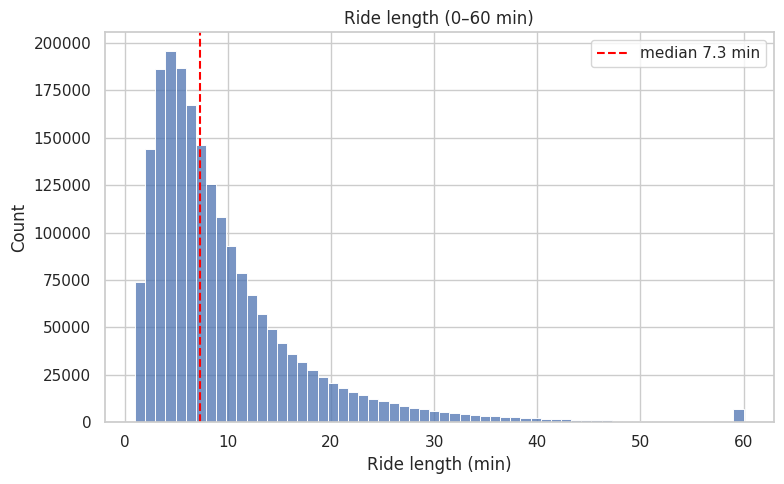

In [92]:
df["ride_length_s"] = (df["ended_at"] - df["started_at"]).dt.total_seconds()
df["ride_length_min"] = df["ride_length_s"] / 60

print("Ride length (minutes) summary:")
print((df["ride_length_s"] / 60).agg(["mean", "median", "min", "max", "std"]).round(2))

negative = (df["ride_length_s"] < 0).sum()
long_rides = (df["ride_length_s"] > 4 * 3600).sum()
print(f"\nRides with negative duration : {negative}")
print(f"Rides longer than 4 hours    : {long_rides}")

# Every trip is kept
plt.figure(figsize=(8, 5))
sns.histplot(df["ride_length_min"].clip(lower=0, upper=60), bins=60)
plt.axvline(df["ride_length_min"].median(), color="red", ls="--",
            label=f"median {df['ride_length_min'].median():.1f} min")
plt.title("Ride length (0\u201360 min)")
plt.xlabel("Ride length (min)")
plt.legend()
plt.tight_layout()
plt.show()

Ride length is strongly **right-skewed**: most trips last only a few to ~20 minutes (the
histogram is zoomed to the first hour), with a thin tail stretching to much longer rides. No
trips are excluded here. The few **negative** durations (clock/data glitches where a trip ends
before it starts) and rides over **4 hours** (more likely a bike that was never docked correctly
than a genuine 4-hour trip) are kept and folded into the edge bins, and are quantified above. The
distribution starts at 1 minute because Citi Bike removes trips shorter than 60 seconds at the
source (likely false starts or re-docking), so there are no zero-length trips.

### 1.3 Trip Distance

Trip distance (km) summary:
mean          2.299990
median        1.725619
min           0.000000
max       11259.076059
std          11.350530
Name: trip_distance_km, dtype: float64


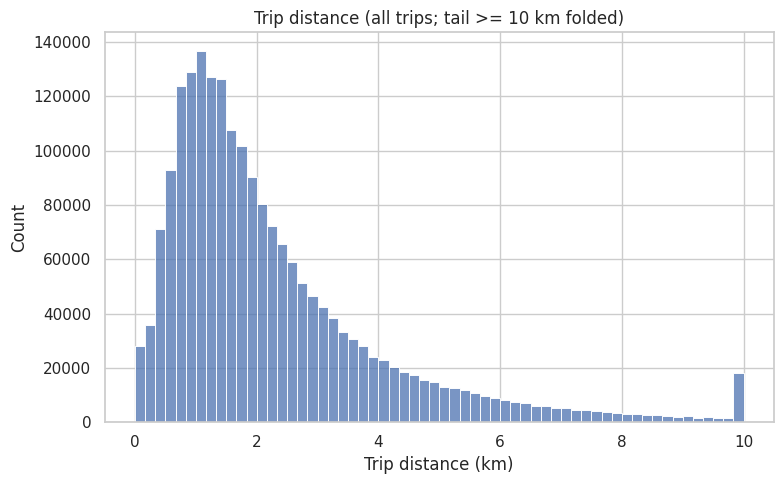

In [93]:
# Straight-line distance between start and end stations, scaled by the circuity factor
df["trip_distance_km"] = haversine_km(
    df["start_lat"], df["start_lng"], df["end_lat"], df["end_lng"]
)

print("Trip distance (km) summary:")
print(df["trip_distance_km"].agg(["mean", "median", "min", "max", "std"]))

# Nothing is excluded
cap = 10  # km; distances above this collapse into the last bin
plt.figure(figsize=(8, 5))
sns.histplot(df["trip_distance_km"].clip(upper=cap), bins=60)
plt.xlabel("Trip distance (km)")
plt.title("Trip distance (all trips; tail >= 10 km folded)")
plt.tight_layout()
plt.show()

This is the **straight-line** distance between the start and end stations, scaled by a 1.3
circuity factor to approximate the real on-street path. No trips are excluded: **round trips**
that begin and end at the same station appear as the **0 km** bar (the straight-line metric
cannot capture their real path), and the long-distance tail is folded into the final bin
so these anomalies stay visible. Both must be considered when interpreting the distribution or
computing distance-based statistics (e.g., average distance per trip, average speed).

### 1.4 Bike Type and User Type

The objective of this analysis is to understand the relationship between bike type and user type. The first panel shows the **bike-type mix within each user type**. Meanwhile the second panel displays the **median ride length by user and bike type**.

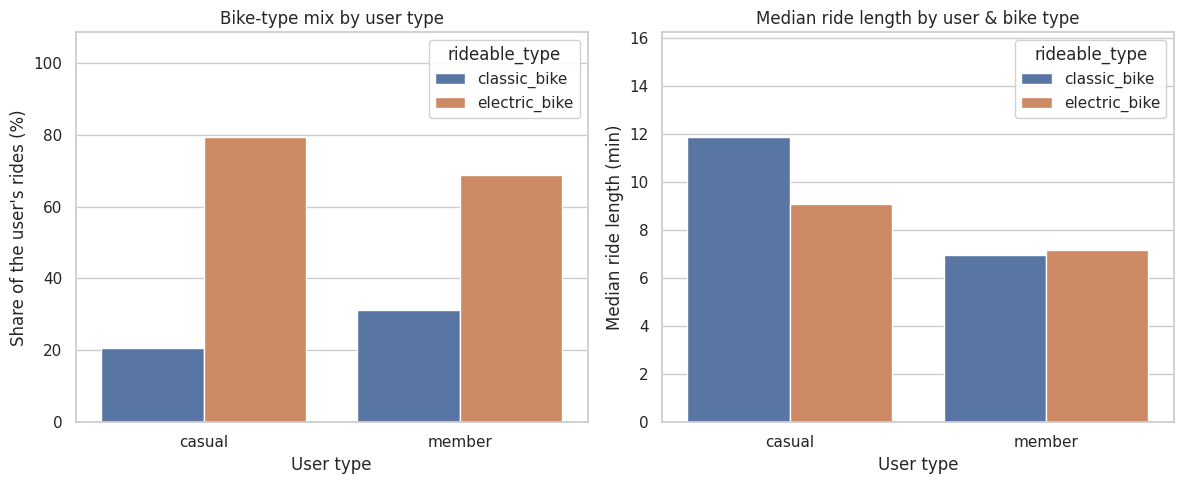

Share of rides by user type (%):
member_casual
member    90.5
casual     9.5
Name: proportion, dtype: float64

Share of rides by bike type (%):
rideable_type
electric_bike    69.7
classic_bike     30.3
Name: proportion, dtype: float64


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bike-type mix *within* each user type (share, not raw volume)
counts = df.groupby(["member_casual", "rideable_type"]).size().reset_index(name="rides")
counts["share"] = 100 * counts["rides"] / counts.groupby("member_casual")["rides"].transform("sum")
sns.barplot(data=counts, x="member_casual", y="share", hue="rideable_type", ax=axes[0])
axes[0].set(title="Bike-type mix by user type", xlabel="User type",
            ylabel="Share of the user's rides (%)")

# Median ride length by user and bike type
med = (df.groupby(["member_casual", "rideable_type"])["ride_length_min"]
         .median().reset_index())
sns.barplot(data=med, x="member_casual", y="ride_length_min", hue="rideable_type", ax=axes[1])
axes[1].set(title="Median ride length by user & bike type", xlabel="User type",
            ylabel="Median ride length (min)")

# Add headroom and pin each legend to the top-right so it never overlaps a bar.
for ax in axes:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
    ax.legend(title="rideable_type", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

# Overall composition, for context.
print("Share of rides by user type (%):")
print((df["member_casual"].value_counts(normalize=True) * 100).round(1))
print("\nShare of rides by bike type (%):")
print((df["rideable_type"].value_counts(normalize=True) * 100).round(1))

Raw volume is dominated by **members** (commuter use), but that count alone is not very
informative. Splitting each dimension by the other is more revealing. **Bike-type mix** (left):
**casual** riders lean more heavily on **electric** bikes than members do. **Ride length**
(right): casual riders take **longer** trips than members on both bike types, while members ride a
steady, short duration regardless of bike type, consistent with frequent short-hop commuting versus
occasional, mostly-electric leisure trips.

### 1.5 Temporal Patterns

Our purpose here is to explore the temporal patterns of bike usage, including daily and weekly trends, through the ride counts. 

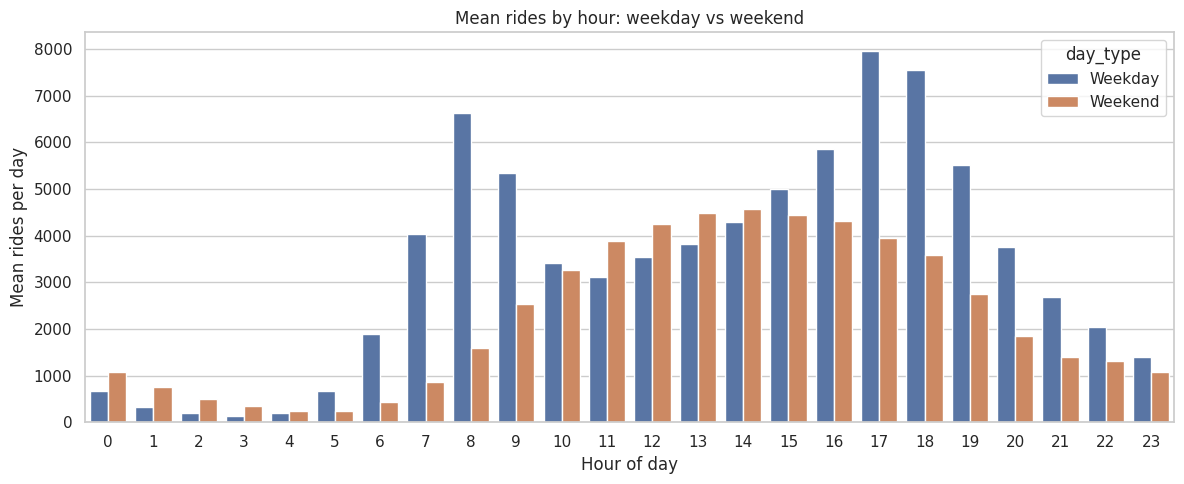

In [95]:
# Hour and weekday are taken from the END timestamp, matching the ingestion pipeline
df["hour"] = df["ended_at"].dt.hour
df["day_of_week"] = df["ended_at"].dt.day_name()
df["date"] = df["ended_at"].dt.date
df["day_type"] = np.where(
    df["ended_at"].dt.weekday < 5, "Weekday", "Weekend"
)

# Mean rides per hour, separating weekdays from weekends.
hourly = (
    df.groupby(["date", "hour", "day_type"]).size().reset_index(name="rides")
)
mean_rides = hourly.groupby(["hour", "day_type"])["rides"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x="hour", y="rides", hue="day_type", data=mean_rides)
plt.xlabel("Hour of day")
plt.ylabel("Mean rides per day")
plt.title("Mean rides by hour: weekday vs weekend")
plt.tight_layout()
plt.show()

Weekdays show the classic bimodal commuting pattern (peaks around 8 AM and 5-6 PM), while
weekends follow a single midday hump consistent with leisure use.

### 1.6 Spatial Patterns

We explore the spatial patterns of bike usage, using a spatial heatmap to visualize the distribution of bike trips across the city. This analysis helps identify areas with high demand for bike-sharing services.

In [96]:
# Heatmap of trip origins, weighted by how many trips start at each station.
origins = (
    df.dropna(subset=["start_lat", "start_lng", "start_station_name"])
    .groupby("start_station_name")
    .agg(lat=("start_lat", "first"), lon=("start_lng", "first"), rides=("ride_id", "count"))
    .reset_index()
)
bike_map = folium.Map(location=[origins["lat"].mean(), origins["lon"].mean()], zoom_start=12)
HeatMap(origins[["lat", "lon", "rides"]].values.tolist()).add_to(bike_map)
# recreate the map and add a tighter heatmap to reduce the glow
bike_map = folium.Map(location=[origins["lat"].mean(), origins["lon"].mean()], zoom_start=12)
HeatMap(
    origins[["lat", "lon", "rides"]].values.tolist(),
    radius=8,
    blur=6,
    min_opacity=0.3,
    max_zoom=18
).add_to(bike_map)
bike_map

In [97]:
# Station-to-station flow: how many trips run between each ordered station pair.
flow = (
    df.dropna(subset=["start_station_name", "end_station_name"])
    .groupby(["start_station_name", "end_station_name"]).size()
    .reset_index(name="trips")
)
print(f"Distinct station pairs with at least one trip: {len(flow):,}")
print("\nTop 10 station-to-station flows:")
print(flow.sort_values("trips", ascending=False).head(10).to_string(index=False))

Distinct station pairs with at least one trip: 393,405

Top 10 station-to-station flows:
           start_station_name         end_station_name  trips
       Norfolk St & Broome St      Henry St & Grand St    455
          Henry St & Grand St   Norfolk St & Broome St    401
         Jackson Ave & 49 Ave  Franklin St & Dupont St    391
      Franklin St & Dupont St     Jackson Ave & 49 Ave    380
              E 77 St & 1 Ave          2 Ave & E 72 St    373
         55 Ave & Center Blvd     Vernon Blvd & 50 Ave    365
North Moore St & Greenwich St Vesey Pl & River Terrace    360
        Clinton St & Grand St      Henry St & Grand St    344
              W 41 St & 8 Ave          E 48 St & 5 Ave    343
              W 21 St & 6 Ave          9 Ave & W 22 St    332


Demand is highly concentrated: a small set of stations near transit hubs and the business
districts dominate both departures and arrivals, so the heatmap clusters around Midtown and Lower
Manhattan, and the busiest station-to-station flows tend to link these same hubs.

### 1.7 Data Quality

#### Missing Values

A small share of trips have missing values, and they are confined to the **station** columns.
The **end-of-trip** fields (`end_station_name`, `end_station_id`, `end_lat`, `end_lng`) are the most
affected probably due to trips ending away from a station. The non-station columns (`ride_id`, `rideable_type`, `started_at`,
`ended_at`, `member_casual`) have no missing values. The table below reports the missing count and
percentage for every raw column.

In [98]:
raw_cols = ["ride_id", "rideable_type", "started_at", "ended_at",
            "start_station_name", "start_station_id", "end_station_name", "end_station_id",
            "start_lat", "start_lng", "end_lat", "end_lng", "member_casual"]
missing = df[raw_cols].isna().sum()
missing = (pd.DataFrame({"missing": missing, "pct (%)": (missing / len(df) * 100).round(2)})
           .sort_values("missing", ascending=False))
print(f"{len(df):,} trips loaded; missing values per column:")
missing

2,031,257 trips loaded; missing values per column:


,missing,pct (%)
end_station_id,4777,0.24
end_lat,4756,0.23
end_lng,4756,0.23
end_station_name,4454,0.22
start_station_name,673,0.03
start_lat,673,0.03
start_station_id,673,0.03
start_lng,673,0.03
ride_id,0,0.00
ended_at,0,0.00


#### Trip Outliers

A handful of trips are clearly not ordinary rides. Some are **too long**
which points to a bike that was never returned rather than a continuous ride. Others cover **zero
straight-line distance** because they start and end at the same station (round trips the
point-to-point distance cannot capture). A few are **impossibly far** caused by
broken station coordinates (an endpoint at latitude/longitude 0, 0). The table below shows
examples of each.

In [99]:
cols = ["started_at", "ride_length_min", "trip_distance_km",
        "start_station_name", "end_station_name", "member_casual"]
too_long = (df[(df["trip_distance_km"] > 0) & df["end_station_name"].notna()]
            .nlargest(3, "ride_length_min")[cols].assign(issue="too long"))
zero_dist = (df[df["trip_distance_km"] == 0]
             .nlargest(3, "ride_length_min")[cols].assign(issue="zero distance (round trip)"))
too_far = (df[df["trip_distance_km"] > 4000]
           .nlargest(2, "trip_distance_km")[cols].assign(issue="too far (bad coordinates)"))
print(f"trips over 24 h           : {int((df['ride_length_min'] > 24 * 60).sum()):,}")
print(f"zero-distance round trips : {int((df['trip_distance_km'] == 0).sum()):,}")
print(f"trips over 4000 km        : {int((df['trip_distance_km'] > 4000).sum()):,}")
pd.concat([too_long, zero_dist, too_far]).round({"ride_length_min": 0, "trip_distance_km": 2})

trips over 24 h           : 315
zero-distance round trips : 27,422
trips over 4000 km        : 2


,started_at,ride_length_min,trip_distance_km,start_station_name,end_station_name,member_casual,issue
1114758,2025-02-19 15:28:47.062,1491.0,2.42,19 St & 8 Ave,Parade Pl & Crooke Ave,casual,too long
1014588,2025-02-25 21:21:47.629,1486.0,7.21,Prospect Pl & Vanderbilt Ave,Nassau Ave & Newell St,member,too long
1948106,2025-02-19 11:02:16.038,1483.0,1.37,Bedford Ave & Nassau Ave,N 5 St & Northside Piers,casual,too long
1678060,2025-02-25 11:23:48.341,1489.0,0.00,Rutland Rd & Brooklyn Ave,Rutland Rd & Brooklyn Ave,member,zero distance (round trip)
473041,2025-02-10 09:22:12.040,1439.0,0.00,Carlton Ave & Dean St,Carlton Ave & Dean St,member,zero distance (round trip)
1765013,2025-02-25 12:14:31.648,1411.0,0.00,Lispenard St & Broadway,Lispenard St & Broadway,member,zero distance (round trip)
250027,2025-02-12 11:32:44.680,13.0,11259.08,Morgan Bike Mechanics,Bronx WH station,member,too far (bad coordinates)
1969442,2025-02-22 13:03:17.335,14.0,11259.08,Morgan Bike Mechanics,Bronx WH station,member,too far (bad coordinates)


#### Different Structure

Citi Bike's trip-file schema changed around **2020**. Files from **2013-2019** (and the Jersey
City `JC-*` files) use a **legacy** layout: space-separated column names, a `bikeid`, a `usertype`
of `Subscriber`/`Customer`, and rider demographics (`gender`, `birth year`); they carry no
`ride_id` and no `rideable_type` (electric bikes did not exist yet). From **2020** onward the
files use the **modern** schema analysed above.


In [100]:
# Compare the two actual schemas: the modern layout (2020+, loaded above) and the legacy
# pre-2020 layout that `load_rides` maps onto it via LEGACY_RENAME.
MODERN = ["ride_id", "rideable_type", "started_at", "ended_at",
          "start_station_name", "start_station_id", "end_station_name", "end_station_id",
          "start_lat", "start_lng", "end_lat", "end_lng", "member_casual"]
assert all(c in df.columns for c in MODERN)  # these are the loaded modern file's raw columns

modern_to_legacy = {v: k for k, v in LEGACY_RENAME.items()}
modern_to_legacy["member_casual"] = "usertype"
notes = {
    "ride_id": "added - unique trip id",
    "rideable_type": "added - classic vs electric (e-bikes)",
    "member_casual": "renamed + recoded (Subscriber->member, Customer->casual)",
}
rows = [{"Modern (2020+)": c,
         "Legacy (2013-2019)": modern_to_legacy.get(c, "-"),
         "Change": notes.get(c, "renamed")}
        for c in MODERN]
for leg, note in [("tripduration", "dropped - derivable from timestamps"),
                  ("bikeid", "dropped - physical bike id"),
                  ("birth year", "dropped - rider demographic"),
                  ("gender", "dropped - rider demographic")]:
    rows.append({"Modern (2020+)": "-", "Legacy (2013-2019)": leg, "Change": note})

print(f"Loaded month uses the {'LEGACY' if meta['is_legacy'] else 'MODERN'} schema.")
pd.DataFrame(rows)

Loaded month uses the MODERN schema.


,Modern (2020+),Legacy (2013-2019),Change
0,ride_id,-,added - unique trip id
1,rideable_type,-,added - classic vs electric (e-bikes)
2,started_at,starttime,renamed
3,ended_at,stoptime,renamed
4,start_station_name,start station name,renamed
5,start_station_id,start station id,renamed
6,end_station_name,end station name,renamed
7,end_station_id,end station id,renamed
8,start_lat,start station latitude,renamed
9,start_lng,start station longitude,renamed


## 2. Station Metadata (GBFS)

Current station information and live availability from the Lyft GBFS feed (the same feed the
backend uses). Two endpoints are merged based on `station_id`: `station_information` (static: name, location, capacity)
and `station_status` (live: bikes/docks available, operational flags).

In [101]:
info = requests.get(GBFS_INFO_URL, timeout=(5, 30)).json()["data"]["stations"]
status = requests.get(GBFS_STATUS_URL, timeout=(5, 30)).json()["data"]["stations"]
status_map = {s["station_id"]: s for s in status}

rows = []
for s in info:
    st = status_map.get(s["station_id"], {})
    counts = {v.get("vehicle_type_id"): v.get("count", 0)
              for v in st.get("vehicle_types_available", [])}
    rows.append({
        "station_id": s["station_id"],
        "short_name": s.get("short_name"),
        "name": s.get("name"),
        "lat": s.get("lat"),
        "lon": s.get("lon"),
        "capacity": s.get("capacity"),
        "num_bikes_available": st.get("num_bikes_available"),
        "num_classic": counts.get("1"),
        "num_ebikes": counts.get("2"),
        "num_ebikes_reported": st.get("num_ebikes_available"),
        "num_docks_available": st.get("num_docks_available"),
        "num_bikes_disabled": st.get("num_bikes_disabled"),
        "num_docks_disabled": st.get("num_docks_disabled"),
        "is_installed": st.get("is_installed"),
        "is_renting": st.get("is_renting"),
        "is_returning": st.get("is_returning"),
    })
stations = pd.DataFrame(rows)
stations["active"] = (
    (stations["is_installed"] == 1) & (stations["is_renting"] == 1) & (stations["is_returning"] == 1)
)
print(f"Stations in feed: {len(stations)}  (active: {stations['active'].sum()})")
stations.head()

Stations in feed: 2462  (active: 2361)


,station_id,short_name,name,lat,lon,capacity,num_bikes_available,num_classic,num_ebikes,num_ebikes_reported,num_docks_available,num_bikes_disabled,num_docks_disabled,is_installed,is_renting,is_returning,active
0,b713367c-3572-4225-b74a-9319ab537838,8539.02,Sedgwick Ave & Hall of Fame Terrace,40.859532,-73.913303,19,0,0,0,0,0,0,0,0,0,0,False
1,66dd1f44-0aca-11e7-82f6-3863bb44ef7c,5785.05,Greenpoint Ave & Manhattan Ave,40.730260,-73.953940,27,0,0,0,0,0,0,0,0,0,0,False
2,06439006-11b6-44f0-8545-c9d39035f32a,5216.06,Vesey St & Church St,40.712220,-74.010472,78,0,0,0,0,0,0,0,0,0,0,False
3,0f45bcf6-7028-4584-a51e-4129847dbebc,5788.15,4 Ave & E 12 St,40.732647,-73.990110,39,0,0,0,0,0,0,0,0,0,0,False
4,1795146692060860976,7983.02,Longfellow Ave & Aldus St,40.823194,-73.887629,24,0,0,0,0,0,0,0,0,0,0,False


### 2.1 Structure

We provide a brief overview of the merged table's structure, including column names, data types, and sample records, through the `pandas` library.

Two **extracted features** are derived on top of the raw feed fields. `active` combines the three operational flags (`is_installed`, `is_renting`, `is_returning`) into a single boolean, used to filter unavailable stations out of live views. `num_classic` and `num_ebikes` split the bikes at a station by vehicle type: the feed reports availability as a list of `(vehicle_type_id, count)` pairs, so it is indexed by type id (`"1"` classic, `"2"` electric), and a type absent from that list leaves no count.

The e-bike count is also published directly as `num_ebikes_available`, kept here as `num_ebikes_reported` so the two sources can be compared — they do not always agree, as section 2.5 shows.

In [102]:
stations.info()

print("\nExtracted features (first rows):")
print(stations[["short_name", "num_bikes_available", "num_classic", "num_ebikes",
                "is_installed", "is_renting", "is_returning", "active"]].head())

<class 'pandas.DataFrame'>
RangeIndex: 2462 entries, 0 to 2461
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_id           2462 non-null   str    
 1   short_name           2462 non-null   str    
 2   name                 2462 non-null   str    
 3   lat                  2462 non-null   float64
 4   lon                  2462 non-null   float64
 5   capacity             2462 non-null   int64  
 6   num_bikes_available  2462 non-null   int64  
 7   num_classic          2462 non-null   int64  
 8   num_ebikes           2462 non-null   int64  
 9   num_ebikes_reported  2462 non-null   int64  
 10  num_docks_available  2462 non-null   int64  
 11  num_bikes_disabled   2462 non-null   int64  
 12  num_docks_disabled   2462 non-null   int64  
 13  is_installed         2462 non-null   int64  
 14  is_renting           2462 non-null   int64  
 15  is_returning         2462 non-null   int64  
 16 

### 2.2 Station Capacity

We look at how the network is provisioned, through the **distribution of station capacity**: how many docks each station has, and how many stations share a given size.

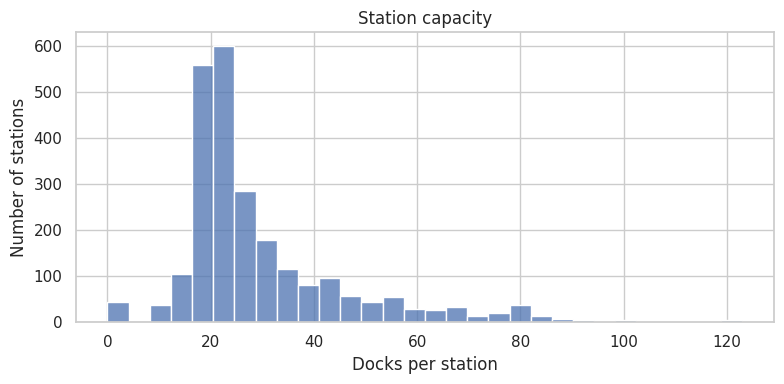

Stations                  : 2462
Median docks per station  : 23
Stations with capacity 0  : 42


In [103]:
# How the network is provisioned: how many docks each station has.
# Inactive stations are kept here, which is what produces the bar at 0 (see 2.5).
plt.figure(figsize=(8, 4))
sns.histplot(stations["capacity"].dropna(), bins=30)
plt.title("Station capacity")
plt.xlabel("Docks per station")
plt.ylabel("Number of stations")
plt.tight_layout()
plt.show()

print(f"Stations                  : {len(stations)}")
print(f"Median docks per station  : {stations['capacity'].median():.0f}")
print(f"Stations with capacity 0  : {int((stations['capacity'] == 0).sum())}")

Capacity distinguishes **small stations** from the **larger hubs** that anchor the busiest areas, which is what the dashboard encodes when sizing station markers. The bar at **0 docks** is not corrupt data: those are stations that appear in the feed but are not physically installed, as quantified in section 2.5.

### 2.3 Live Availability

We now turn to the current state of the network: where the bikes are **right now**. The bars answer different questions: `num_bikes_available` is how many bikes are parked and rentable, `num_docks_available` how many empty docks are free to receive one. Together with the bikes that are docked but **out of service** they account for the network's total capacity.

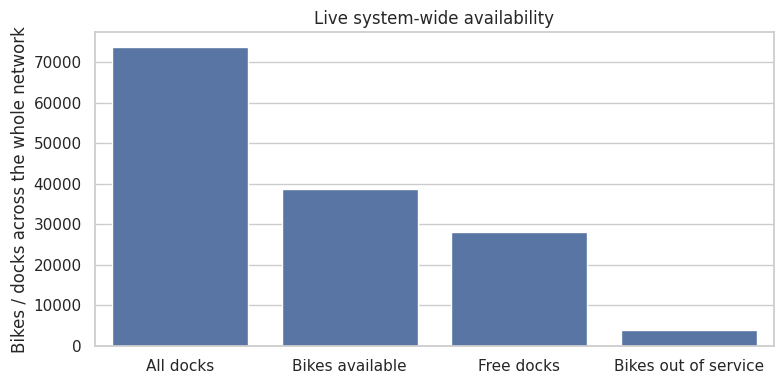

All docks (capacity) : 73,654
Bikes available      : 38,624  (of which e-bikes: 18,174)
Free docks           : 28,200
Bikes out of service : 3,782
Unaccounted docks    : 3,048


In [104]:
# Live snapshot: these totals change on every run.
# "All docks" is the network's total capacity, i.e. every dock whether occupied or not,
# and gives the other three bars a reference to be read against.
avail = pd.Series({
    "All docks": stations["capacity"].sum(),
    "Bikes available": stations["num_bikes_available"].sum(),
    "Free docks": stations["num_docks_available"].sum(),
    "Bikes out of service": stations["num_bikes_disabled"].sum(),
})
plt.figure(figsize=(8, 4))
sns.barplot(x=avail.index, y=avail.values)
plt.title("Live system-wide availability")
plt.xlabel("")
plt.ylabel("Bikes / docks across the whole network")
plt.tight_layout()
plt.show()

accounted = avail["Bikes available"] + avail["Free docks"] + avail["Bikes out of service"]
print(f"All docks (capacity) : {int(avail['All docks']):,}")
print(f"Bikes available      : {int(avail['Bikes available']):,}"
      f"  (of which e-bikes: {int(stations['num_ebikes'].sum()):,})")
print(f"Free docks           : {int(avail['Free docks']):,}")
print(f"Bikes out of service : {int(avail['Bikes out of service']):,}")
print(f"Unaccounted docks    : {int(avail['All docks'] - accounted):,}")

There are usually **more bikes available than free docks**, which is expected rather than an inconsistency: it simply means most docks in the network are currently occupied, so the system sits above half full.

Reading the other three bars against **All docks** also exposes a data-quality issue. Bikes available, free docks and bikes out of service should together account for the whole capacity, but they fall short of it, so a share of the network's docks is reported by no counter at all. Section 2.5 quantifies this reconciliation gap per station.

Because this is a **live snapshot**, every number here changes between runs, so it describes the state of the system at fetch time rather than a reproducible property of the dataset.

### 2.4 Station Status

The feed is a **registry of known stations**, not a list of working ones, so it also carries stations that cannot currently be used. We break the network down by operational status to see how much of it is actually in service, and how much capacity is held by stations that are not.

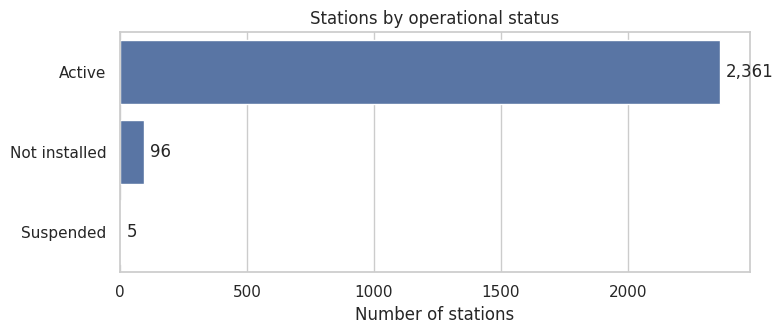

Docks held by unusable stations : 1,994 of 73,654 (2.7%)
Bikes stranded at those stations : 0
Partially disabled (renting XOR returning): 0


In [105]:
# Split the network by why a station is unusable, rather than just active vs inactive.
not_installed = stations["is_installed"] == 0
suspended = (stations["is_installed"] == 1) & ~stations["active"]

by_status = pd.Series({
    "Active": stations["active"].sum(),
    "Not installed": not_installed.sum(),
    "Suspended": suspended.sum(),
})

plt.figure(figsize=(8, 3.5))
ax = sns.barplot(x=by_status.values, y=by_status.index, orient="h")
for i, v in enumerate(by_status.values):
    ax.text(v + by_status.max() * 0.01, i, f"{int(v):,}", va="center")
plt.title("Stations by operational status")
plt.xlabel("Number of stations")
plt.ylabel("")
plt.tight_layout()
plt.show()

inactive = stations[~stations["active"]]
print(f"Docks held by unusable stations : {int(inactive['capacity'].sum()):,} "
      f"of {int(stations['capacity'].sum()):,} "
      f"({100 * inactive['capacity'].sum() / stations['capacity'].sum():.1f}%)")
print(f"Bikes stranded at those stations : {int(inactive['num_bikes_available'].sum()):,}")
print(f"Partially disabled (renting XOR returning): "
      f"{int(((stations['is_renting'] == 1) ^ (stations['is_returning'] == 1)).sum())}")

The overwhelming majority of stations are usable, and the unusable ones split into two clearly separated causes. **Not installed** dominates: these are entries registered ahead of a physical rollout, or kept after removal, and they are the same stations that produce the zero-capacity bar in section 2.2. A much smaller group is **suspended**, meaning physically installed but currently neither renting nor returning.

Notably the three operational flags almost never disagree: essentially no station is partially disabled, allowing rentals while refusing returns or vice versa. This is what justifies collapsing them into the single boolean `active` rather than modelling each flag separately in the dashboard.

The unusable stations still hold a non-trivial share of the network's docks, which is why they must be excluded before computing any capacity statistic, but they hold no bikes, so they cannot distort availability figures.

### 2.5 Data Quality

#### Inactive Stations and Zero Capacity

The feed is a **registry, not a list of working stations**: entries stay in it while a station is being installed, is temporarily out of service, or is being removed. Those stations are flagged by the operational flags rather than dropped, which is what the `active` feature captures.

Zero capacity is the visible symptom of the same thing, and explains the bar at 0 in the capacity histogram. The stations reporting `capacity = 0` are not missing a value: they are entries that are **not installed**, and consequently report no docks and no bikes. Treating that 0 as a real station size would understate the network's average capacity, so these rows are excluded from live views through `active` rather than through a capacity filter.

In [106]:
print(f"Stations in feed          : {len(stations)}")
print(f"Inactive (not installed/renting/returning): {(~stations['active']).sum()}")
print(f"Stations with capacity 0  : {int((stations['capacity'] == 0).sum())}")

# Zero capacity is not a missing value: those stations are simply not installed yet.
zero_cap = stations[stations["capacity"] == 0]
print(f"  ...of which inactive    : {int((~zero_cap['active']).sum())} / {len(zero_cap)}")
print(f"  ...holding any bike     : {int((zero_cap['num_bikes_available'] > 0).sum())}")

print("\nMissing values per column:")
missing_s = stations.isna().sum()
print(missing_s[missing_s > 0] if missing_s.any() else "  none")

Stations in feed          : 2462
Inactive (not installed/renting/returning): 101
Stations with capacity 0  : 42
  ...of which inactive    : 42 / 42
  ...holding any bike     : 0

Missing values per column:
  none


#### Identifier Consistency

The numeric `station_id` from GBFS is **not** the identifier used in the historical trip files —
those use the public `short_name`. Any join between live station metadata and trip data must go
through `short_name`.

#### Feed Self-Consistency

The feed reports the same quantities in more than one way, which lets us check it against itself. Two identities should hold at every station: the docks must add up (`bikes available + free docks + bikes out of service + docks out of service = capacity`), and the per-type bike counts must add up to the reported total (`classic + e-bikes = bikes available`).

Neither holds everywhere. The dock identity is the weaker of the two, and the gap it leaves is exactly what makes the bars in section 2.3 fall short of total capacity: for a share of stations some docks are reported by no counter at all. Most mismatches are tiny, but the tail reaches stations where a large part of the capacity is unaccounted for, so any figure derived from capacity should be read as approximate.

The bike-type identity fails at only a handful of stations, but it matters more than its size suggests, because it is the one our own extracted features are built on. The feed publishes the e-bike count **twice**, once as a dedicated `num_ebikes_available` field and once inside the `vehicle_types_available` list, and where the two disagree it is the vehicle-type entry that fails to reconcile with the reported total.

Stations with capacity > 0     : 2,420
  docks reconcile exactly      : 1,609 (66.5%)
  within +/- 2 docks           : 94.8%
  largest shortfall            : -111 docks


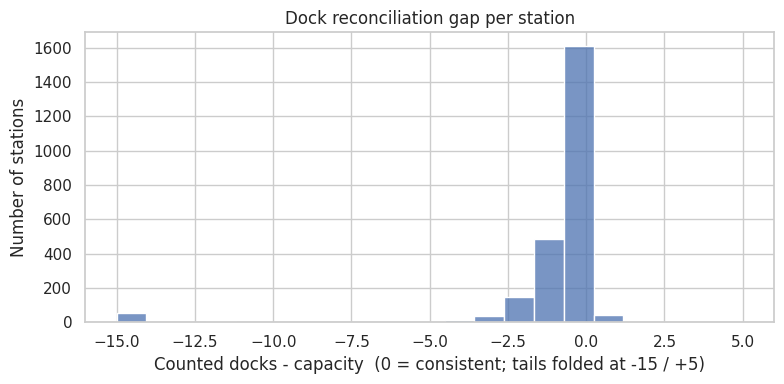


classic + vehicle_types e-bikes  == num_bikes_available : 2,421 / 2,462
classic + num_ebikes_available   == num_bikes_available : 2,456 / 2,462
the two e-bike sources disagree at : 35 stations


In [107]:
# Identity 1: every dock should be accounted for by exactly one counter.
sized = stations[stations["capacity"] > 0].copy()
sized["dock_gap"] = (
    sized["num_bikes_available"] + sized["num_docks_available"]
    + sized["num_bikes_disabled"] + sized["num_docks_disabled"].fillna(0)
    - sized["capacity"]
)
print(f"Stations with capacity > 0     : {len(sized):,}")
print(f"  docks reconcile exactly      : {int((sized['dock_gap'] == 0).sum()):,} "
      f"({100 * (sized['dock_gap'] == 0).mean():.1f}%)")
print(f"  within +/- 2 docks           : {100 * (sized['dock_gap'].abs() <= 2).mean():.1f}%")
print(f"  largest shortfall            : {int(sized['dock_gap'].min())} docks")

plt.figure(figsize=(8, 4))
sns.histplot(sized["dock_gap"].clip(lower=-15, upper=5), bins=21)
plt.title("Dock reconciliation gap per station")
plt.xlabel("Counted docks - capacity  (0 = consistent; tails folded at -15 / +5)")
plt.ylabel("Number of stations")
plt.tight_layout()
plt.show()

# Identity 2: the per-type counts should add up to the reported bike total.
type_sum = stations["num_classic"] + stations["num_ebikes"]
field_sum = stations["num_classic"] + stations["num_ebikes_reported"]
print(f"\nclassic + vehicle_types e-bikes  == num_bikes_available : "
      f"{int((type_sum == stations['num_bikes_available']).sum()):,} / {len(stations):,}")
print(f"classic + num_ebikes_available   == num_bikes_available : "
      f"{int((field_sum == stations['num_bikes_available']).sum()):,} / {len(stations):,}")
print(f"the two e-bike sources disagree at : "
      f"{int((stations['num_ebikes'] != stations['num_ebikes_reported']).sum())} stations")

#### Missing Values and Cleaning

The fields we consume are fully populated in the feed, so there is no imputation step: the checks above report the missing counts on each run, and the only structurally optional values are `num_classic` and `num_ebikes`, which stay empty for a station whose `vehicle_types_available` list omits that type.

The pipeline therefore performs **no cleaning** of station metadata. Ingestion keeps every station the feed returns and only casts types, the loader keeps `short_name`, `name`, `lat` and `lon` (capacity is not persisted) and de-duplicates with `ON CONFLICT DO NOTHING`, and the inactive stations described above are filtered by the backend **at request time** through `active`, not removed from storage. The inconsistencies found in this section are therefore surfaced, not corrected.

## 3. Weather Data

Hourly NYC weather from the [Open-Meteo archive API](https://open-meteo.com/), used to relate
ridership to weather. We fetch the full calendar year covering the ride data so seasonality is
visible even when only one ride month is loaded.

In [108]:
ride_year = df["started_at"].min().year
start_date = date(ride_year, 1, 1)
end_date = min(date(ride_year, 12, 31), date.today() - timedelta(days=1))

resp = requests.get(
    WEATHER_API_URL,
    params={
        "latitude": NYC_LAT,
        "longitude": NYC_LON,
        "start_date": start_date.isoformat(),
        "end_date": end_date.isoformat(),
        "hourly": "temperature_2m,precipitation,weather_code,wind_speed_10m",
        "timezone": "America/New_York",
        "wind_speed_unit": "kmh",
    },
    timeout=(5, 120),
)
resp.raise_for_status()

weather = pd.DataFrame(resp.json()["hourly"])
weather["datetime"] = pd.to_datetime(weather["time"])
weather = weather.drop(columns="time")
print(f"Fetched {len(weather):,} hourly rows: {start_date} -> {end_date}")
weather.head()

Fetched 8,760 hourly rows: 2025-01-01 -> 2025-12-31


,temperature_2m,precipitation,weather_code,wind_speed_10m,datetime
0,7.6,3.7,63,17.3,2025-01-01 00:00:00
1,8.3,0.9,53,14.9,2025-01-01 01:00:00
2,8.7,0.0,3,7.8,2025-01-01 02:00:00
3,8.9,0.0,3,8.8,2025-01-01 03:00:00
4,8.9,0.0,3,8.8,2025-01-01 04:00:00


### 3.1 Structure and Summary

In [109]:
weather.info()
print("\nSummary statistics:")
weather[["temperature_2m", "wind_speed_10m", "precipitation", "weather_code"]].describe()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   temperature_2m  8760 non-null   float64       
 1   precipitation   8760 non-null   float64       
 2   weather_code    8760 non-null   int64         
 3   wind_speed_10m  8760 non-null   float64       
 4   datetime        8760 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 342.3 KB

Summary statistics:


,temperature_2m,wind_speed_10m,precipitation,weather_code
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,12.431233,10.096347,0.122614,9.054909
std,10.659041,5.386688,0.613330,19.003351
min,-16.300000,0.000000,0.000000,0.000000
25%,3.600000,6.000000,0.000000,0.000000
50%,13.000000,9.400000,0.000000,2.000000
75%,21.000000,13.400000,0.000000,3.000000
max,39.300000,31.200000,15.400000,75.000000


### 3.2 Distributions and Seasonality

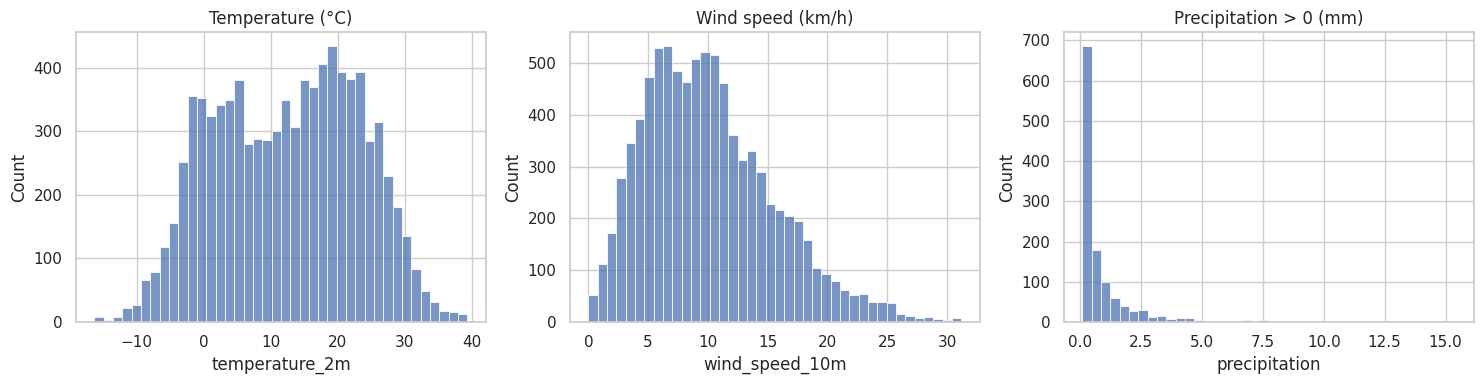

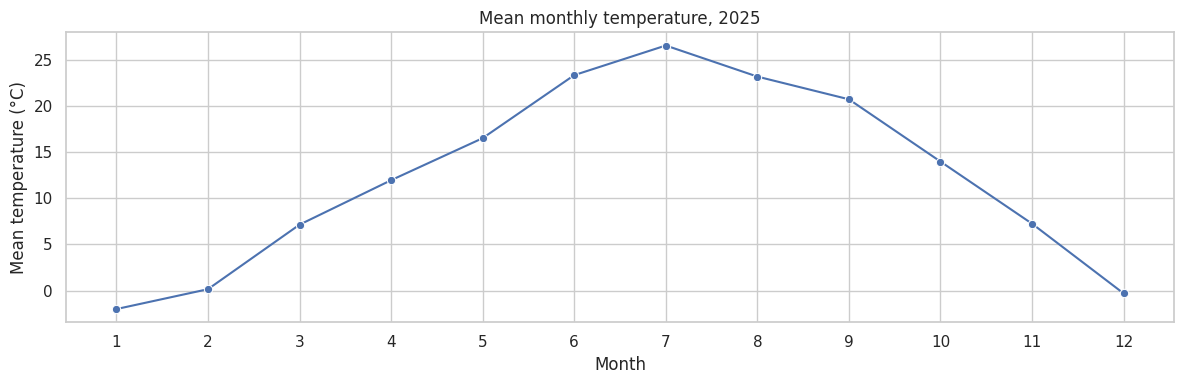

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(weather["temperature_2m"], bins=40, ax=axes[0]).set(title="Temperature (°C)")
sns.histplot(weather["wind_speed_10m"], bins=40, ax=axes[1]).set(title="Wind speed (km/h)")
sns.histplot(weather.loc[weather["precipitation"] > 0, "precipitation"], bins=40, ax=axes[2]).set(
    title="Precipitation > 0 (mm)")
plt.tight_layout()
plt.show()

weather["month"] = weather["datetime"].dt.month
monthly_temp = weather.groupby("month")["temperature_2m"].mean()
plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_temp.index, y=monthly_temp.values, marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean temperature (°C)")
plt.title(f"Mean monthly temperature, {ride_year}")
plt.tight_layout()
plt.show()

Temperature follows the expected annual cycle (cold winters, warm summers), while precipitation is
**zero for most hours** with occasional spikes — a heavily right-skewed variable, which is why the
histogram only shows the non-zero values.

### 3.3 Ridership vs. Weather

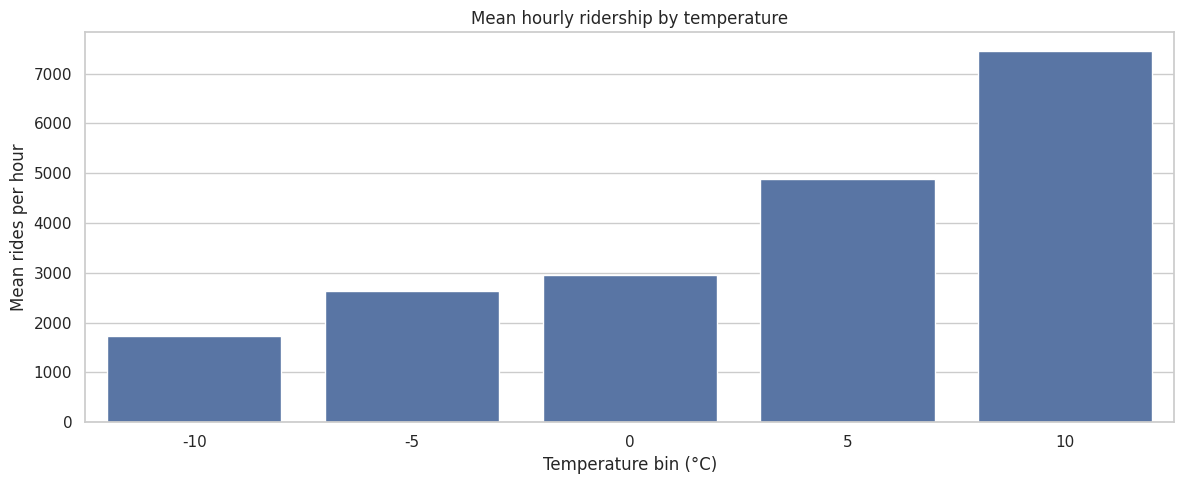

In [111]:
# Join hourly ride counts to the matching weather hour and look at rides vs. temperature.
# Hour taken from the END timestamp, consistent with the pipeline and the rest of the notebook.
df["hour_ts"] = df["ended_at"].dt.floor("h")
rides_per_hour = df.groupby("hour_ts").size().reset_index(name="rides")
merged = rides_per_hour.merge(weather, left_on="hour_ts", right_on="datetime", how="inner")

merged["temp_bin"] = (merged["temperature_2m"] // 5 * 5).astype(int)
by_temp = merged.groupby("temp_bin")["rides"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x="temp_bin", y="rides", data=by_temp)
plt.xlabel("Temperature bin (°C)")
plt.ylabel("Mean rides per hour")
plt.title("Mean hourly ridership by temperature")
plt.tight_layout()
plt.show()

Ridership rises with temperature up to a comfortable range and drops off in the cold — confirming
weather is a useful predictor of demand, which is the main reason this dataset is included.

### 3.4 Data Quality

In [112]:
missing_w = weather.isna().sum()
print("Missing values per column:")
print(missing_w[missing_w > 0] if missing_w.any() else "  none")
print(f"\nHours expected vs. present: "
      f"{int((end_date - start_date).total_seconds() // 3600) + 24} vs. {len(weather)}")

Missing values per column:
  none

Hours expected vs. present: 8760 vs. 8760


## 4. Bike Lanes

NYC's bike-route network from [NYC OpenData](https://data.cityofnewyork.us/) (dataset `mzxg-pwib`),
used to render bike infrastructure. Each row is a route segment with a `the_geom` geometry, the
street, facility class, borough, status and installation/retirement dates.

In [113]:
routes = pd.read_csv(BIKE_ROUTES_URL, low_memory=False)
print("Shape:", routes.shape)
print("Columns:", routes.columns.tolist())
routes.head()

Shape: (28983, 25)
Columns: ['the_geom', 'segmentid', 'bikeid', 'prevbikeid', 'status', 'boro', 'street', 'fromstreet', 'tostreet', 'onoffst', 'facilitycl', 'allclasses', 'bikedir', 'lanecount', 'ft_facilit', 'tf_facilit', 'ft2facilit', 'tf2facilit', 'instdate', 'ret_date', 'grnwy', 'gwsystem', 'gwsys2', 'spur', 'gwyjuris']


,the_geom,segmentid,bikeid,prevbikeid,status,boro,street,fromstreet,tostreet,onoffst,facilitycl,allclasses,bikedir,lanecount,ft_facilit,tf_facilit,ft2facilit,tf2facilit,instdate,ret_date,grnwy,gwsystem,gwsys2,spur,gwyjuris
0,MULTILINESTRING ((-74.192429667502 40.52174149...,2579,6562,NaN,Current,5,HYLAN BLVD,HOLTEN AV,LUTEN AV,ON,II,II,2,2,Curbside Buffered,Curbside Buffered,NaN,NaN,10/01/2007,NaN,Greenway,Staten Island Waterfront,NaN,Main Alignment,NYCDOT
1,MULTILINESTRING ((-74.16031384424598 40.589027...,5033,4272,NaN,Current,5,MERRYMOUNT ST,RICHMOND HILL RD,ROCKLAND AV,ON,II,II,2,2,Conventional Buffered,Conventional Buffered,NaN,NaN,08/12/2021,NaN,NaN,NaN,NaN,NaN,NaN
2,MULTILINESTRING ((-74.12631986979562 40.635252...,10186,2107,NaN,Current,5,CLOVE ROAD,RICHMOND TERR,FOREST AVE,ON,III,III,2,2,Shared,Shared,NaN,NaN,09/11/2015,NaN,NaN,NaN,NaN,NaN,NaN
3,MULTILINESTRING ((-74.00973537112554 40.645666...,20716,942,NaN,Current,3,5 AV,23 ST,50 ST,ON,III,III,2,2,Shared,Shared,NaN,NaN,07/02/2013,NaN,NaN,NaN,NaN,NaN,NaN
4,MULTILINESTRING ((-74.02089492413252 40.626542...,126857,951,NaN,Current,3,6 AVENUE,67 ST,FT HAMILTON PKWY,ON,III,III,2,2,Shared,Shared,NaN,NaN,06/29/2015,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1 Breakdowns

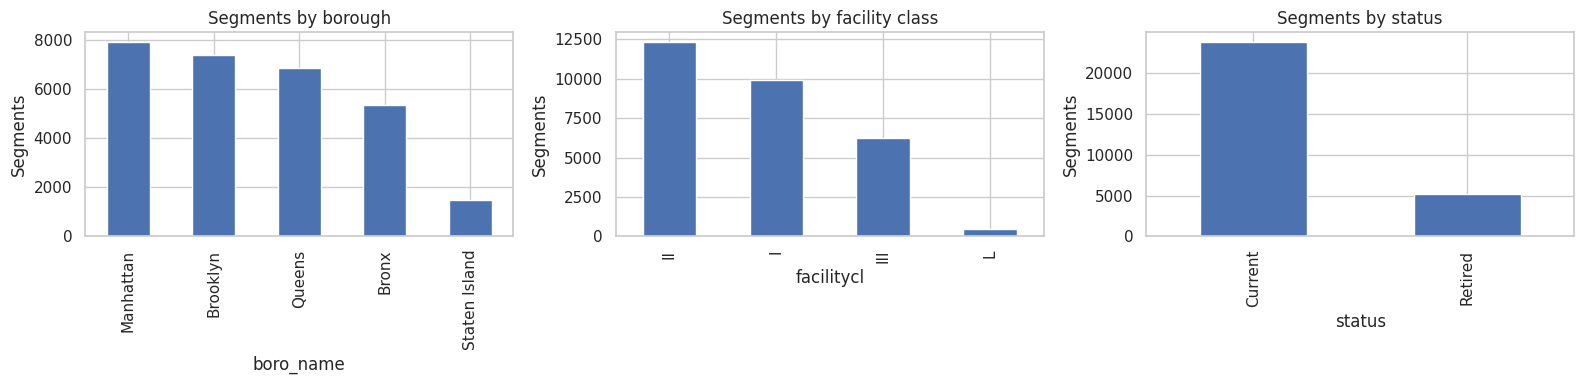

In [114]:
BORO = {1: "Manhattan", 2: "Bronx", 3: "Brooklyn", 4: "Queens", 5: "Staten Island"}
routes["boro_name"] = routes["boro"].map(BORO)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
routes["boro_name"].value_counts().plot.bar(ax=axes[0], title="Segments by borough")
routes["facilitycl"].value_counts().plot.bar(ax=axes[1], title="Segments by facility class")
routes["status"].value_counts().plot.bar(ax=axes[2], title="Segments by status")
for ax in axes:
    ax.set_ylabel("Segments")
plt.tight_layout()
plt.show()

Segments concentrate in Manhattan and Brooklyn, and most are **current** rather than retired. The
facility class encodes the level of protection (e.g. protected paths vs. shared/sharrow lanes),
which matters for how the network is rendered in the visualization.

### 4.2 Installation Timeline

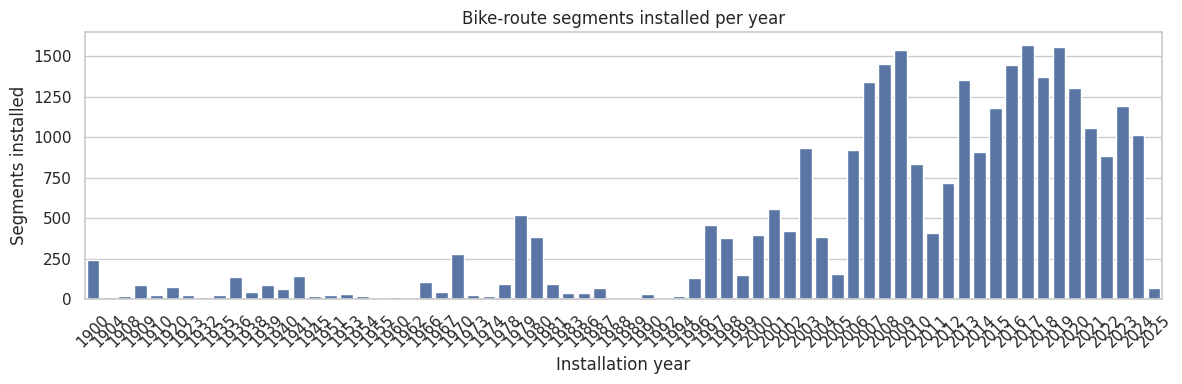

In [115]:
routes["install_year"] = pd.to_datetime(
    routes["instdate"], errors="coerce"
).dt.year
by_year = routes["install_year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.barplot(x=by_year.index.astype(int), y=by_year.values)
plt.xticks(rotation=45)
plt.xlabel("Installation year")
plt.ylabel("Segments installed")
plt.title("Bike-route segments installed per year")
plt.tight_layout()
plt.show()

The installation timeline tracks how NYC's bike network has expanded over the years (note that
`instdate` is missing for some legacy segments, so the earliest years are under-counted).

### 4.3 Map of the Network

In [116]:
# Extract polylines ([[lat, lon], ...]) from a (MULTI)LINESTRING WKT string.
def parse_wkt_lines(wkt):
    if not isinstance(wkt, str):
        return []
    lines = []
    for group in re.findall(r"\(([^()]+)\)", wkt):
        pts = []
        for pair in group.split(","):
            parts = pair.split()
            if len(parts) >= 2:
                lon, lat = float(parts[0]), float(parts[1])  # WKT is lon-lat
                pts.append([lat, lon])
        if pts:
            lines.append(pts)
    return lines

# Draw a sample of segments to keep the map light.
sample = routes.dropna(subset=["the_geom"]).head(800)
routes_map = folium.Map(location=[NYC_LAT, NYC_LON], zoom_start=11)
for geom in sample["the_geom"]:
    for line in parse_wkt_lines(geom):
        folium.PolyLine(line, color="crimson", weight=2, opacity=0.6).add_to(routes_map)
routes_map

### 4.4 Data Quality

In [117]:
quality_cols = ["the_geom", "instdate", "ret_date", "facilitycl", "boro", "street"]
miss = routes[quality_cols].isna().sum()
print("Missing values (selected columns):")
print(pd.DataFrame({"missing": miss, "pct": (miss / len(routes) * 100).round(1)}))
print(f"\nUnmapped borough codes: {routes['boro_name'].isna().sum()}")
print(f"Segments with unparseable installation date: {routes['install_year'].isna().sum()}")

Missing values (selected columns):
            missing   pct
the_geom          0   0.0
instdate          0   0.0
ret_date      23810  82.2
facilitycl        0   0.0
boro              0   0.0
street            0   0.0

Unmapped borough codes: 0
Segments with unparseable installation date: 0
